# K-Nearest Neighbors (KNN)

Este algoritmo está basado en instancias que clasifican un punto según el voto mayoritario de sus "k" vecinos más cercanos en el espacio euclidiano. Permite evaluar la hipótesis de agrupamiento espacial. Es decir, nos ayuda a descubrir si los usuarios que abandonan Spotify (Churn) tienden a ser geométricamente similares y se agrupan en "vecindarios" específicos dentro del hiperespacio de características.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc)

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import umap
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import trustworthiness

In [3]:
df = pd.read_csv("spotify_churn_dataset.csv")

## Preprocesamiento de los datos

In [4]:
print("Eliminando user_id ya que es un identificador sin varianza predictiva.")
df = df.drop(columns=['user_id'])
print("Eliminando offline_listening por su alta correlación negativa con ads_per_week")
df = df.drop(columns=['offline_listening'])

Eliminando user_id ya que es un identificador sin varianza predictiva.
Eliminando offline_listening por su alta correlación negativa con ads_per_week


In [5]:
# Separar características (X) y variable objetivo (y)
X = df.drop('is_churned', axis=1)
y = df['is_churned']

Usamos *stratify=y* en el split para asegurarnos que en el `train_test_split`, tanto el conjunto de entrenamiento como el de prueba mantengan la proporción original del *74/26*.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")

Dimensiones de X_train: (6400, 9)
Dimensiones de X_test: (1600, 9)


In [7]:
num_cols = ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week']
cat_cols = ['gender', 'country', 'subscription_type', 'device_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(f"Dimensiones después de codificar: {X_train_transformed.shape}")

Dimensiones después de codificar: (6400, 19)


## Implementación del KNN

In [8]:
# 1. Definir el pipeline
pipeline_knn = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

# 2. Malla de hiperparámetros
param_grid_knn = {
    'knn__n_neighbors': [3, 7, 15, 25],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

# 3. Configurar GridSearchCV
grid_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 4. Entrenar con los datos
grid_knn.fit(X_train_transformed, y_train)

print("\n--- MEJORES HIPERPARÁMETROS (KNN) ---")
print(grid_knn.best_params_)

# 5. Evaluación en el conjunto de Test
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_transformed)
y_pred_proba_knn = best_knn.predict_proba(X_test_transformed)[:, 1]

print("\n--- REPORTE DE CLASIFICACIÓN (KNN) ---")
print(classification_report(y_test, y_pred_knn))

print(f"AUC-ROC Score (KNN): {roc_auc_score(y_test, y_pred_proba_knn):.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

--- MEJORES HIPERPARÁMETROS (KNN) ---
{'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'uniform'}

--- REPORTE DE CLASIFICACIÓN (KNN) ---
              precision    recall  f1-score   support

           0       0.76      0.62      0.68      1186
           1       0.28      0.43      0.34       414

    accuracy                           0.57      1600
   macro avg       0.52      0.53      0.51      1600
weighted avg       0.64      0.57      0.59      1600

AUC-ROC Score (KNN): 0.5409


Matriz de confusión

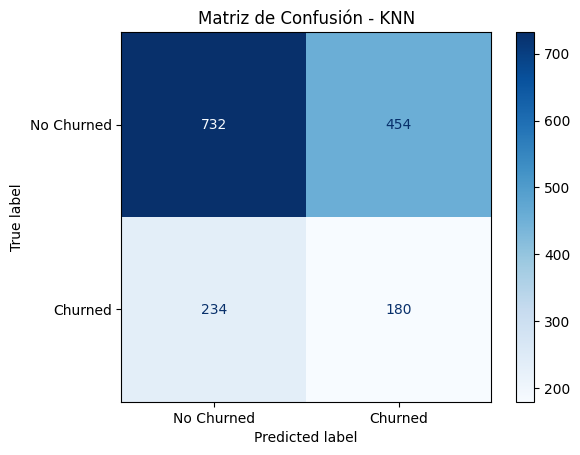

In [12]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No Churned', 'Churned'])
disp_knn.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - KNN')
plt.show()

Curva AUC-ROC

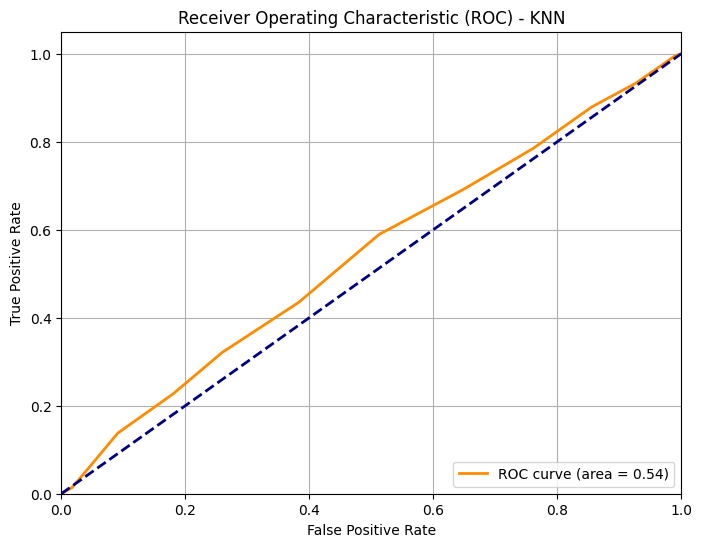

In [22]:
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_pred_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - KNN')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Redimensión de características

### KNN con PCA

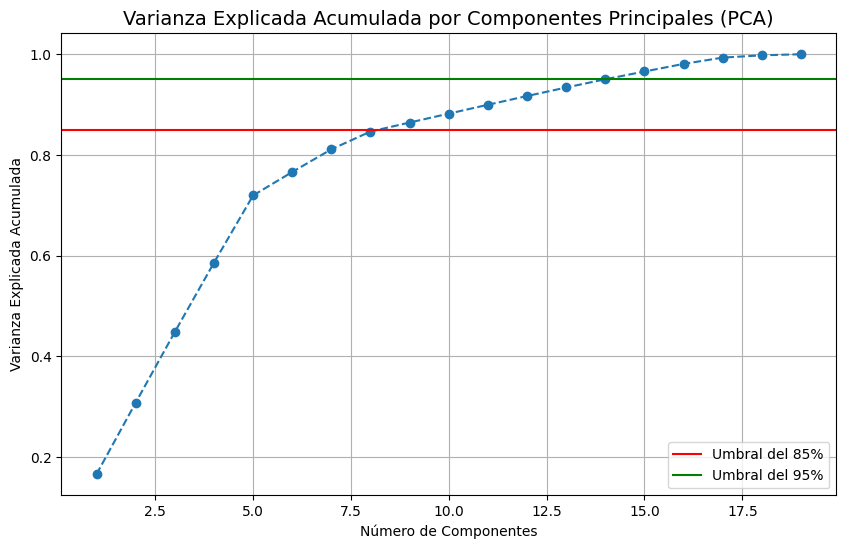

In [9]:
pca_test = PCA()
pca_test.fit(X_train_transformed)

varianza_acumulada = np.cumsum(pca_test.explained_variance_ratio_)

# Gráfico para justificar la elección de componentes
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')
plt.axhline(y=0.85, color='r', linestyle='-', label='Umbral del 85%') # Nuestra línea de decisión
plt.axhline(y=0.95, color='g', linestyle='-', label='Umbral del 95%')

plt.title('Varianza Explicada Acumulada por Componentes Principales (PCA)', fontsize=14)
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.legend()
plt.grid(True)
plt.show()

Se seleccionó el umbral del 85% de varianza explicada acumulada, correspondiente a 8 componentes principales. Este criterio se apoya en el análisis del scree plot, donde la curva presenta un aplanamiento notable a partir del octavo componente, indicando que los componentes adicionales aportan información marginal. Esto representa una reducción del 58% en la dimensionalidad original.

In [12]:
pca = PCA(n_components=0.85)
X_train_pca = pca.fit_transform(X_train_transformed)
X_test_pca  = pca.transform(X_test_transformed)
reduccion = (1 - X_train_pca.shape[1] / X_train_transformed.shape[1]) * 10

print(f"Features originales: {X_train_transformed.shape[1]} → componentes PCA: {X_train_pca.shape[1]}")
print(f"Varianza explicada: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Porcentaje de reducción: {reduccion:.1f}%")

pipeline_knn_pca = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

grid_knn_pca = GridSearchCV(
    estimator=pipeline_knn_pca,
    param_grid=param_grid_knn,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_knn_pca.fit(X_train_pca, y_train)

best_knn_pca = grid_knn_pca.best_estimator_
y_pred_knn_pca = best_knn_pca.predict(X_test_pca)
y_pred_proba_knn_pca = best_knn_pca.predict_proba(X_test_pca)[:, 1]

print("\n--- MEJORES HIPERPARÁMETROS (KNN + PCA) ---")
print(grid_knn_pca.best_params_)
print("\n--- REPORTE DE CLASIFICACIÓN (KNN + PCA) ---")
print(classification_report(y_test, y_pred_knn_pca))
print(f"AUC-ROC Score (KNN + PCA): {roc_auc_score(y_test, y_pred_proba_knn_pca):.4f}")

Features originales: 19 → componentes PCA: 9
Varianza explicada: 86.43%
Porcentaje de reducción: 5.3%
Fitting 5 folds for each of 16 candidates, totalling 80 fits

--- MEJORES HIPERPARÁMETROS (KNN + PCA) ---
{'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}

--- REPORTE DE CLASIFICACIÓN (KNN + PCA) ---
              precision    recall  f1-score   support

           0       0.75      0.62      0.68      1186
           1       0.28      0.42      0.33       414

    accuracy                           0.57      1600
   macro avg       0.52      0.52      0.51      1600
weighted avg       0.63      0.57      0.59      1600

AUC-ROC Score (KNN + PCA): 0.5174


Matriz de confusión

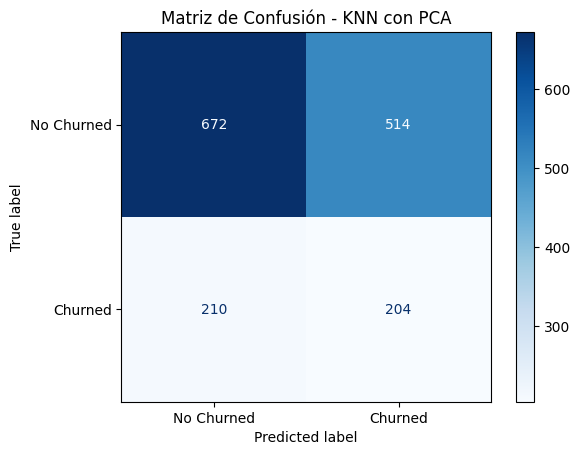

In [23]:
cm_knn_pca = confusion_matrix(y_test, y_pred_knn_pca)
disp_knn_pca = ConfusionMatrixDisplay(confusion_matrix=cm_knn_pca, display_labels=['No Churned', 'Churned'])
disp_knn_pca.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - KNN con PCA')
plt.show()

Curva ROC-AUC

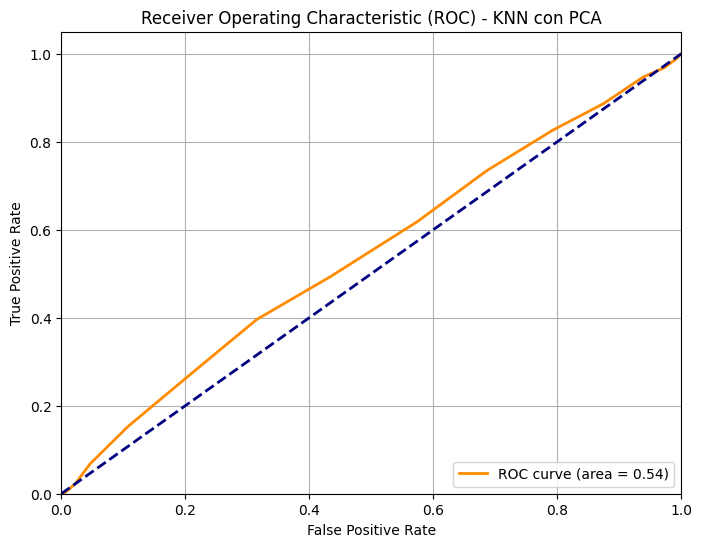

In [24]:
fpr_knn_pca, tpr_knn_pca, thresholds_knn_pca = roc_curve(y_test, y_pred_proba_knn_pca)
roc_auc_knn_pca = auc(fpr_knn_pca, tpr_knn_pca)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn_pca, tpr_knn_pca, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_knn_pca:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - KNN con PCA')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### KNN con UMAP

In [26]:
reducer = umap.UMAP(n_components=5, random_state=42)
X_train_umap = reducer.fit_transform(X_train_transformed)
X_test_umap  = reducer.transform(X_test_transformed)

print(f"Features originales: {X_train.shape[1]} → componentes UMAP: {X_train_umap.shape[1]}")

pipeline_knn_umap = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

grid_knn_umap = GridSearchCV(
    estimator=pipeline_knn_umap,
    param_grid=param_grid_knn,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_knn_umap.fit(X_train_umap, y_train)

best_knn_umap = grid_knn_umap.best_estimator_
y_pred_knn_umap = best_knn_umap.predict(X_test_umap)
y_pred_proba_knn_umap = best_knn_umap.predict_proba(X_test_umap)[:, 1]

print("\n--- MEJORES HIPERPARÁMETROS (KNN + UMAP) ---")
print(grid_knn_umap.best_params_)
print("\n--- REPORTE DE CLASIFICACIÓN (KNN + UMAP) ---")
print(classification_report(y_test, y_pred_knn_umap))
print(f"AUC-ROC Score (KNN + UMAP): {roc_auc_score(y_test, y_pred_proba_knn_umap):.4f}")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Features originales: 9 → componentes UMAP: 5
Fitting 5 folds for each of 16 candidates, totalling 80 fits

--- MEJORES HIPERPARÁMETROS (KNN + UMAP) ---
{'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'uniform'}

--- REPORTE DE CLASIFICACIÓN (KNN + UMAP) ---
              precision    recall  f1-score   support

           0       0.74      0.53      0.61      1186
           1       0.25      0.46      0.33       414

    accuracy                           0.51      1600
   macro avg       0.50      0.49      0.47      1600
weighted avg       0.61      0.51      0.54      1600

AUC-ROC Score (KNN + UMAP): 0.4909


Matriz de confusión

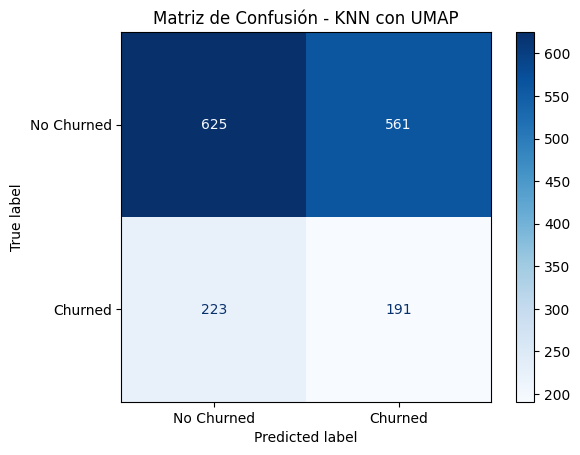

In [27]:
cm_knn_umap = confusion_matrix(y_test, y_pred_knn_umap)
disp_knn_umap = ConfusionMatrixDisplay(confusion_matrix=cm_knn_umap, display_labels=['No Churned', 'Churned'])
disp_knn_umap.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - KNN con UMAP')
plt.show()

Curva ROC-AUC

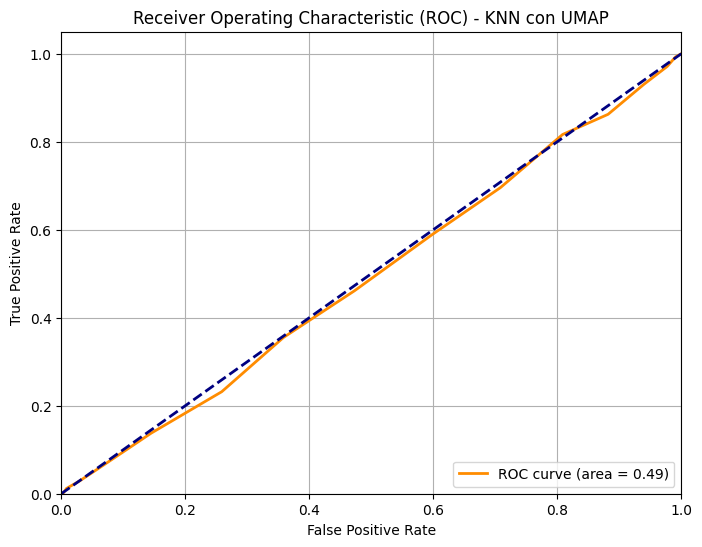

In [36]:
fpr_knn_umap, tpr_knn_umap, thresholds_knn_umap = roc_curve(y_test, y_pred_proba_knn_umap)
roc_auc_knn_umap = auc(fpr_knn_umap, tpr_knn_umap)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn_umap, tpr_knn_umap, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_knn_umap:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - KNN con UMAP')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### KNN con LDA

In [31]:
# LDA como reductor (supervisado, usa y_train)
lda = LinearDiscriminantAnalysis()
X_train_lda = lda.fit_transform(X_train_transformed, y_train)  # necesita y_train
X_test_lda  = lda.transform(X_test_transformed)

print(f"Features originales: {X_train_transformed.shape[1]} → componentes LDA: {X_train_lda.shape[1]}")

# Pipeline y GridSearch
pipeline_knn_lda = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier())
])

grid_knn_lda = GridSearchCV(
    estimator=pipeline_knn_lda,
    param_grid=param_grid_knn,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_knn_lda.fit(X_train_lda, y_train)

best_knn_lda = grid_knn_lda.best_estimator_
y_pred_knn_lda = best_knn_lda.predict(X_test_lda)
y_pred_proba_knn_lda = best_knn_lda.predict_proba(X_test_lda)[:, 1]

print("\n--- MEJORES HIPERPARÁMETROS (KNN + LDA) ---")
print(grid_knn_lda.best_params_)
print("\n--- REPORTE DE CLASIFICACIÓN (KNN + LDA) ---")
print(classification_report(y_test, y_pred_knn_lda))
print(f"AUC-ROC Score (KNN + LDA): {roc_auc_score(y_test, y_pred_proba_knn_lda):.4f}")

Features originales: 19 → componentes LDA: 1
Fitting 5 folds for each of 16 candidates, totalling 80 fits

--- MEJORES HIPERPARÁMETROS (KNN + LDA) ---
{'knn__metric': 'euclidean', 'knn__n_neighbors': 25, 'knn__weights': 'uniform'}

--- REPORTE DE CLASIFICACIÓN (KNN + LDA) ---
              precision    recall  f1-score   support

           0       0.75      0.55      0.64      1186
           1       0.27      0.47      0.34       414

    accuracy                           0.53      1600
   macro avg       0.51      0.51      0.49      1600
weighted avg       0.62      0.53      0.56      1600

AUC-ROC Score (KNN + LDA): 0.5045


Matriz de confusión

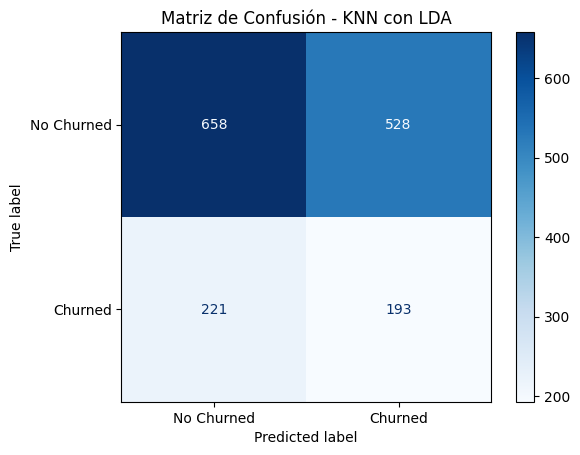

In [33]:
cm_knn_lda = confusion_matrix(y_test, y_pred_knn_lda)
disp_knn_lda = ConfusionMatrixDisplay(confusion_matrix=cm_knn_lda, display_labels=['No Churned', 'Churned'])
disp_knn_lda.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - KNN con LDA')
plt.show()

Curva ROC-AUC

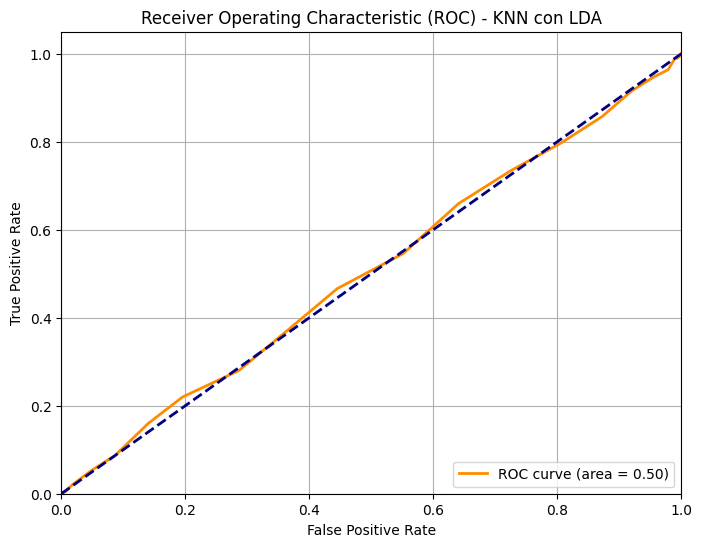

In [35]:
fpr_knn_lda, tpr_knn_lda, thresholds_knn_lda = roc_curve(y_test, y_pred_proba_knn_lda)
roc_auc_knn_lda = auc(fpr_knn_lda, tpr_knn_lda)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn_lda, tpr_knn_lda, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_knn_lda:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - KNN con LDA')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()